# 🌾 Agricultural Yield – Exploratory Data Analysis (EDA)

**Mục tiêu:** Phân tích EDA để chuẩn bị dữ liệu cho mô hình hồi quy dự đoán năng suất cây trồng (Yield).

**Dataset:** `Agri_Data_Cleaned.csv` – 4,178 mẫu × 51 cột, đã được làm sạch.

**Thư viện sử dụng:** `pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy`, `scikit-learn`

---


## 1. Import Libraries & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ── Style Configuration ──────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 11,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
})

COLOR_MAIN = '#2d6a4f'
COLOR_ACC  = '#52b788'
PALETTE    = ['#2d6a4f', '#52b788', '#95d5b2', '#d8f3dc', '#b7e4c7']

print("✅ Libraries loaded successfully")


✅ Libraries loaded successfully


## 2. Load & Inspect Data

In [2]:
# ── Load Dataset ─────────────────────────────────────────────────────────────
df = pd.read_csv('Agri_Data_Cleaned.csv')

print(f"📐 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"🎯 Target column: 'Yield'")
print(f"\n{'='*50}")
print("First 5 rows:")
df.head()


📐 Shape: 4,178 rows × 51 columns
🎯 Target column: 'Yield'

First 5 rows:


,Area,District,Season,Avg Temp,Avg Humidity,Crop Name,Transplant,Growth,Harvest,Production,...,Heat_Stress_Days,Wind_Mean,Wind_Max,Rain_Temp_Ratio,Extreme_Heat_Risk,Is_Extreme_Heat,LST_C,is_extreme_Heat_Stress_Days,is_extreme_Wind_Max,Yield
0,259,Bagerhat,Rabi,17.75,55.0,Wheat,December,Jan To March,April,200.0,...,0.0,1.452917,4.33,11.23,Low Risk,0,24.144525,0,0,0.772201
1,421,Bagerhat,Rabi,20.50,60.0,Maize 2,December,Jan To March,April,946.0,...,0.0,1.452917,4.33,11.23,Low Risk,0,24.144525,0,0,2.247031
2,145439,Bagerhat,Rabi,26.00,72.5,Boro,November,Dec To March,April,268754.0,...,0.0,1.452917,4.33,11.23,Low Risk,0,24.144525,0,0,1.847881
3,627,Bagerhat,Rabi,20.50,80.0,Sweet Potato,November,Dec To March,April,2200.0,...,0.0,1.452917,4.33,11.23,Low Risk,0,24.144525,0,0,3.508772
4,383,Bagerhat,Kharif 1,31.50,70.0,Mango,April,April To May,April To June,1913.0,...,42.5,2.481885,5.86,22.73,High Risk,1,28.431973,1,0,4.994778


In [3]:
# ── Data Types & Basic Info ───────────────────────────────────────────────────
print("📋 Column Data Types:")
print(df.dtypes.to_string())


📋 Column Data Types:
Area                             int64
District                           str
Season                             str
Avg Temp                       float64
Avg Humidity                   float64
Crop Name                          str
Transplant                         str
Growth                             str
Harvest                            str
Production                     float64
Max Temp                         int64
Min Temp                       float64
Max Relative Humidity            int64
Min Relative Humidity            int64
EVI                            float64
LAI                            float64
FPAR                           float64
Soil_Moisture_mm               float64
NDVI_Season_Mean               float64
NDVI_Season_Max                float64
NDVI_Season_Min                float64
NDVI_Season_Std                float64
NDVI_Season_Range              float64
NDVI_Season_CV                 float64
Avg_Salinity_Index             float64
pH  

In [4]:
# ── Missing Values Check ──────────────────────────────────────────────────────
missing = df.isnull().sum()
print(f"✅ Total missing values: {missing.sum()}")
print(f"✅ Dataset is clean – no missing values found!")

# ── Define Feature Groups ─────────────────────────────────────────────────────
numeric_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = ['District', 'Season', 'Crop Name', 'pH_Suitability',
            'Dominant_Soil_Texture', 'Water_Availability_Cat', 'Extreme_Heat_Risk']
target = 'Yield'

key_features = [
    'Avg Temp', 'Avg Humidity', 'Max Temp', 'Min Temp',
    'NDVI_Season_Mean', 'EVI', 'LAI', 'FPAR',
    'Rainfall', 'Soil_Moisture_mm', 'sm_surface', 'sm_rootzone',
    'pH', 'Organic_Carbon', 'Nitrogen', 'Clay', 'Sand', 'Silt',
    'Avg_Salinity_Index', 'Heat_Stress_Days',
    'Wind_Mean', 'Rain_Temp_Ratio', 'LST_C', 'Bulk_Density'
]

print(f"\n📊 Numeric features: {len(numeric_cols)}")
print(f"📝 Categorical features: {len(cat_cols)}")
print(f"🔑 Key analysis features: {len(key_features)}")


✅ Total missing values: 0
✅ Dataset is clean – no missing values found!

📊 Numeric features: 41
📝 Categorical features: 7
🔑 Key analysis features: 24


## 3. Descriptive Statistics

Tính toán thống kê mô tả cho biến mục tiêu **Yield** và các đặc trưng chính.


In [5]:
# ── Target Variable Statistics ───────────────────────────────────────────────
print("🎯 Yield (Target) – Descriptive Statistics:")
print("=" * 45)
stats_yield = df[target].describe()
for k, v in stats_yield.items():
    print(f"  {k:10s}: {v:.4f}")

print(f"  {'Skewness':10s}: {df[target].skew():.4f}")
print(f"  {'Kurtosis':10s}: {df[target].kurt():.4f}")
print(f"  {'CV (%)':10s}: {df[target].std()/df[target].mean()*100:.2f}%")
print()
print("⚠️  Skewness > 5 → Data heavily right-skewed")
print("💡 Recommendation: Use log1p(Yield) as regression target")


🎯 Yield (Target) – Descriptive Statistics:
  count     : 4178.0000
  mean      : 4.1786
  std       : 5.7743
  min       : 0.0139
  25%       : 1.2863
  50%       : 2.5150
  75%       : 4.6623
  max       : 98.9907
  Skewness  : 5.1751
  Kurtosis  : 47.7938
  CV (%)    : 138.19%

⚠️  Skewness > 5 → Data heavily right-skewed
💡 Recommendation: Use log1p(Yield) as regression target


In [6]:
# ── Key Numeric Features – Descriptive Statistics ────────────────────────────
desc_table = df[key_features[:12]].describe().T.round(4)
desc_table['skew'] = df[key_features[:12]].skew().round(4)
print("📊 Descriptive Statistics – Key Features (subset):")
desc_table


📊 Descriptive Statistics – Key Features (subset):


,count,mean,std,min,25%,50%,75%,max,skew
Avg Temp,4178.0,23.9608,4.6897,11.5000,20.0000,25.0000,27.5000,34.5000,-0.1848
Avg Humidity,4178.0,72.6140,9.1680,48.7500,67.5000,72.5000,80.0000,90.0000,-0.6537
Max Temp,4178.0,30.8679,5.8963,15.0000,27.0000,30.0000,35.0000,47.0000,-0.0658
Min Temp,4178.0,17.0537,5.4080,5.0000,14.0000,18.0000,20.0000,27.0000,-0.1535
NDVI_Season_Mean,4178.0,0.3737,0.1061,0.0000,0.3059,0.3889,0.4416,0.6954,-0.3464
EVI,4178.0,0.3444,0.0632,0.1869,0.3065,0.3321,0.3862,0.5059,0.2424
LAI,4178.0,1.3722,0.4497,0.7101,1.0315,1.2896,1.5862,2.4184,0.9411
FPAR,4178.0,0.4625,0.0895,0.2221,0.3989,0.4644,0.5168,0.6937,0.1483
Rainfall,4178.0,856.4484,606.4999,64.7100,158.4400,913.6500,1238.1500,3216.4800,0.4317
Soil_Moisture_mm,4178.0,18.7174,6.1142,8.5520,12.1580,18.7385,25.2963,25.3826,-0.1533


## 4. Target Variable Distribution (Yield)

Phân tích phân phối của biến mục tiêu – xác định xem có cần biến đổi (transform) không.


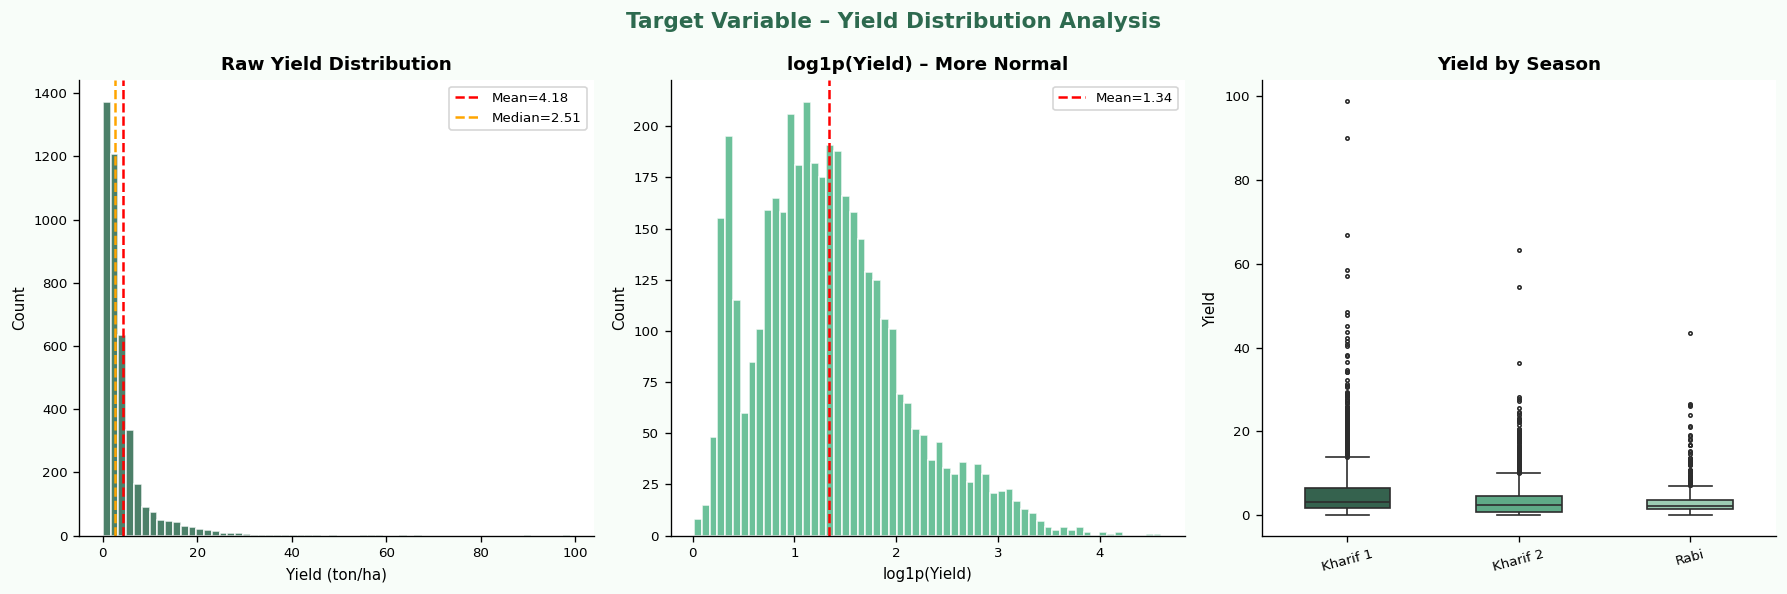


📊 Season Analysis:
          count   mean  median    std
Season                               
Kharif 1   1421  5.875   3.066  7.905
Kharif 2   1569  3.563   2.380  4.554
Rabi       1188  2.963   2.137  3.124


In [7]:
fig = plt.figure(figsize=(15, 5), facecolor='#f8fdf9')
fig.patch.set_facecolor('#f8fdf9')

# 4a. Raw Yield Distribution
ax1 = fig.add_subplot(1, 3, 1)
ax1.hist(df[target], bins=60, color=COLOR_MAIN, edgecolor='white', alpha=0.85)
ax1.axvline(df[target].mean(),   color='red',    lw=1.5, linestyle='--', label=f'Mean={df[target].mean():.2f}')
ax1.axvline(df[target].median(), color='orange', lw=1.5, linestyle='--', label=f'Median={df[target].median():.2f}')
ax1.set_title('Raw Yield Distribution', fontweight='bold')
ax1.set_xlabel('Yield (ton/ha)'); ax1.set_ylabel('Count')
ax1.legend(fontsize=8)

# 4b. log1p(Yield) Distribution
ax2 = fig.add_subplot(1, 3, 2)
log_yield = np.log1p(df[target])
ax2.hist(log_yield, bins=60, color=COLOR_ACC, edgecolor='white', alpha=0.85)
ax2.axvline(log_yield.mean(), color='red', lw=1.5, linestyle='--', label=f'Mean={log_yield.mean():.2f}')
ax2.set_title('log1p(Yield) – More Normal', fontweight='bold')
ax2.set_xlabel('log1p(Yield)'); ax2.set_ylabel('Count')
ax2.legend(fontsize=8)

# 4c. Yield by Season (Boxplot)
ax3 = fig.add_subplot(1, 3, 3)
order = df.groupby('Season')[target].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Season', y=target, order=order, ax=ax3,
            palette=PALETTE[:3], width=0.5, fliersize=2)
ax3.set_title('Yield by Season', fontweight='bold')
ax3.set_xlabel(''); ax3.set_ylabel('Yield')
ax3.tick_params(axis='x', rotation=15)

fig.suptitle('Target Variable – Yield Distribution Analysis',
             fontsize=13, fontweight='bold', color=COLOR_MAIN)
plt.tight_layout()
plt.show()

print(f"\n📊 Season Analysis:")
print(df.groupby('Season')[target].agg(['count','mean','median','std']).round(3).to_string())


## 5. Correlation Analysis

Tính ma trận tương quan giữa các biến số và biến mục tiêu Yield.


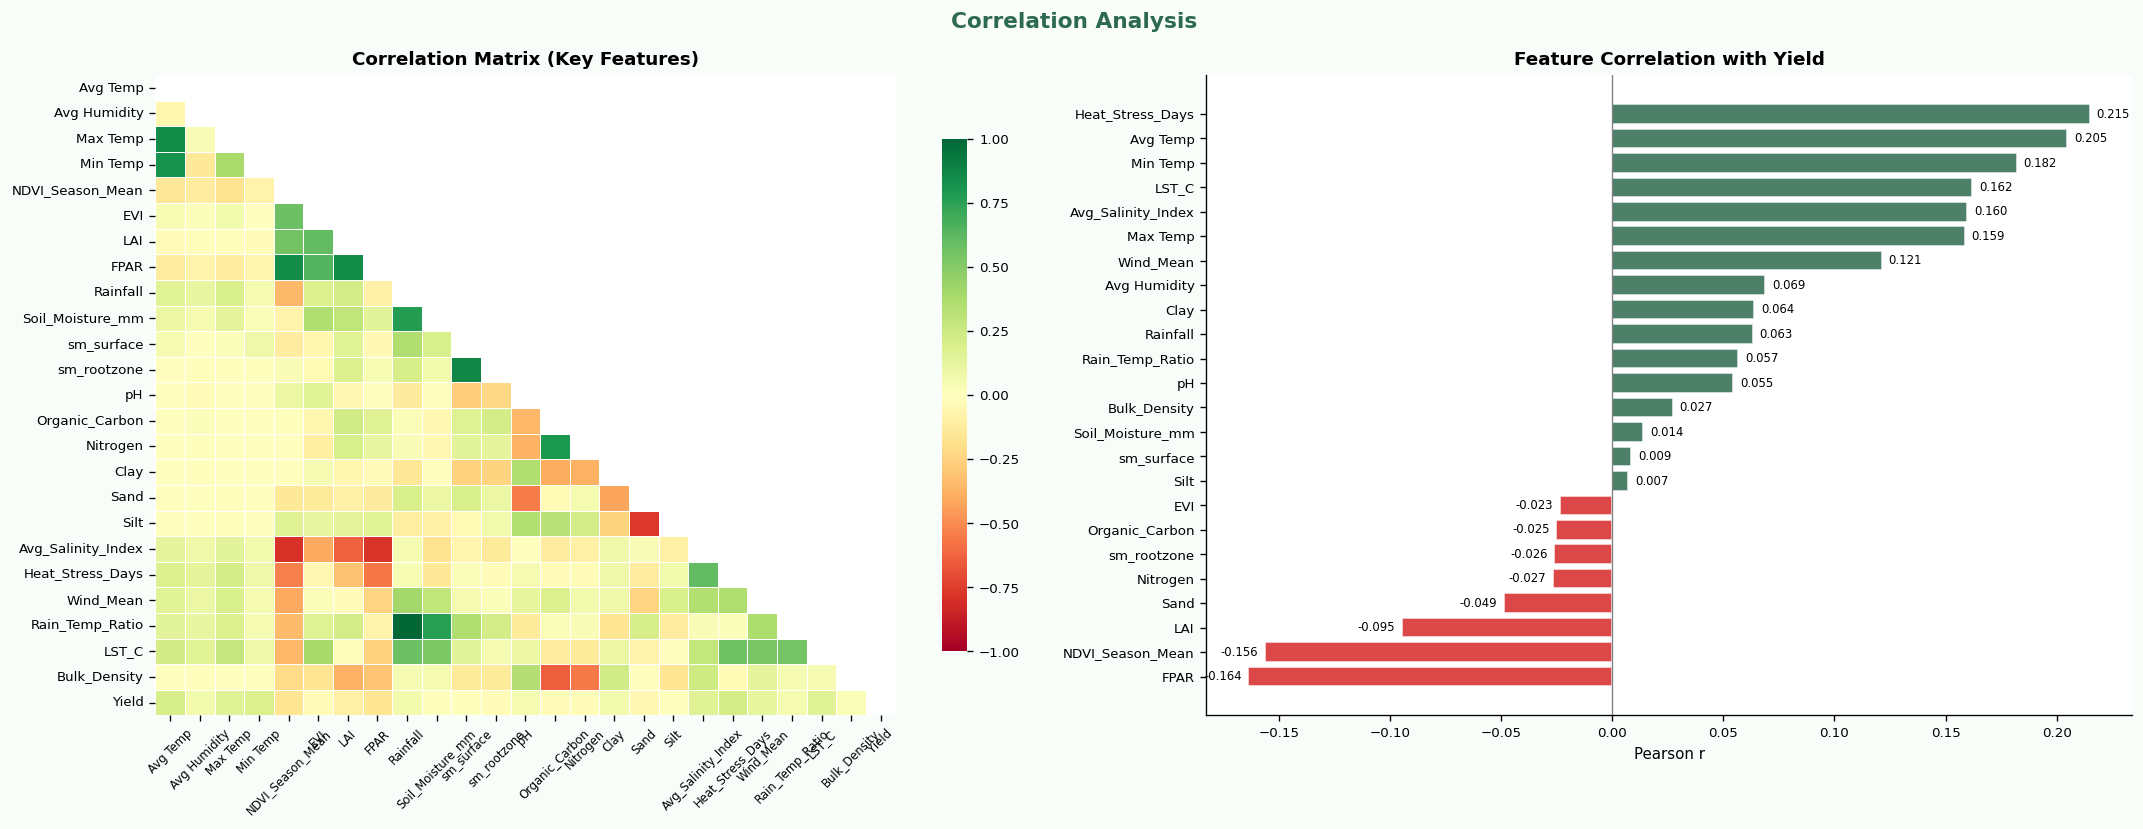

In [8]:
# ── Compute Correlation Matrix ────────────────────────────────────────────────
corr_df     = df[key_features + [target]].copy()
corr_matrix = corr_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor='#f8fdf9')
fig.patch.set_facecolor('#f8fdf9')

# Heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, ax=axes[0], cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, annot=False, linewidths=0.3,
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Correlation Matrix (Key Features)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=7)

# Correlation with Yield – bar chart
corr_yield = corr_matrix[target].drop(target).sort_values()
colors_bar = ['#d62728' if v < 0 else COLOR_MAIN for v in corr_yield.values]
axes[1].barh(corr_yield.index, corr_yield.values, color=colors_bar, edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='gray', lw=0.8)
axes[1].set_title('Feature Correlation with Yield', fontweight='bold')
axes[1].set_xlabel('Pearson r')
for i, v in enumerate(corr_yield.values):
    axes[1].text(v + (0.003 if v >= 0 else -0.003), i, f'{v:.3f}',
                 va='center', ha='left' if v >= 0 else 'right', fontsize=7)

fig.suptitle('Correlation Analysis', fontsize=13, fontweight='bold', color=COLOR_MAIN)
plt.tight_layout()
plt.show()


In [9]:
# ── Top Correlations Summary ──────────────────────────────────────────────────
print("🔼 Top 8 POSITIVE correlations with Yield:")
print(corr_matrix[target].drop(target).sort_values(ascending=False).head(8).to_string())

print("\n🔽 Top 8 NEGATIVE correlations with Yield:")
print(corr_matrix[target].drop(target).sort_values().head(8).to_string())


🔼 Top 8 POSITIVE correlations with Yield:
Heat_Stress_Days      0.214856
Avg Temp              0.204719
Min Temp              0.182102
LST_C                 0.162049
Avg_Salinity_Index    0.159710
Max Temp              0.158630
Wind_Mean             0.121239
Avg Humidity          0.068981

🔽 Top 8 NEGATIVE correlations with Yield:
FPAR               -0.163632
NDVI_Season_Mean   -0.156315
LAI                -0.094773
Sand               -0.048842
Nitrogen           -0.026795
sm_rootzone        -0.026080
Organic_Carbon     -0.025210
EVI                -0.023487


## 6. Scatter Plots – Top Features vs Yield

Visualize mối quan hệ tuyến tính giữa các biến quan trọng nhất và Yield.


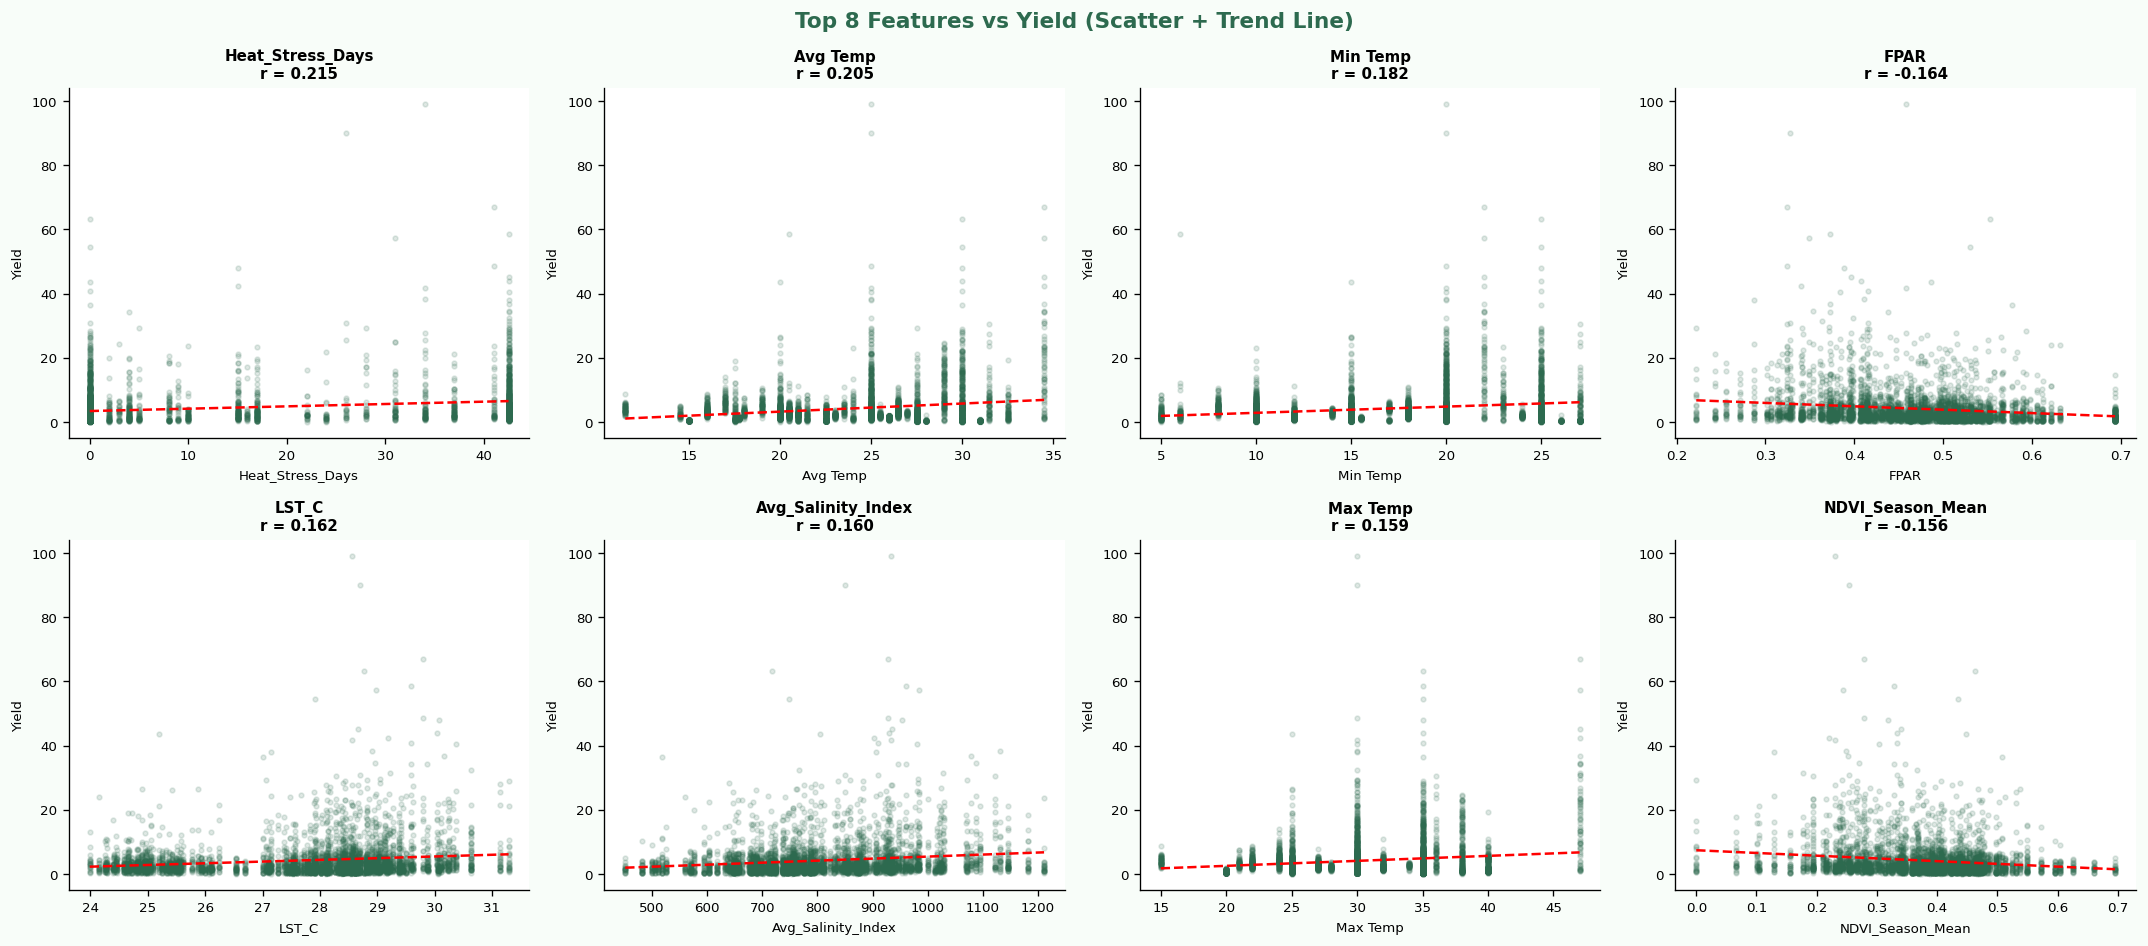

In [10]:
top8 = corr_matrix[target].drop(target).abs().sort_values(ascending=False).head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(18, 8), facecolor='#f8fdf9')
fig.patch.set_facecolor('#f8fdf9')
axes = axes.flatten()

for i, feat in enumerate(top8):
    ax = axes[i]
    r  = corr_matrix.loc[feat, target]
    ax.scatter(df[feat], df[target], alpha=0.15, s=8, color=COLOR_MAIN)
    m, b  = np.polyfit(df[feat].fillna(df[feat].mean()), df[target], 1)
    xline = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(xline, m * xline + b, 'r--', lw=1.5)
    ax.set_xlabel(feat, fontsize=8)
    ax.set_ylabel('Yield', fontsize=8)
    ax.set_title(f'{feat}\nr = {r:.3f}', fontweight='bold', fontsize=9)

fig.suptitle('Top 8 Features vs Yield (Scatter + Trend Line)',
             fontsize=13, fontweight='bold', color=COLOR_MAIN)
plt.tight_layout()
plt.show()


## 7. Categorical Feature Analysis

Phân tích ảnh hưởng của các biến phân loại (Season, District, Crop, Soil...) lên Yield.


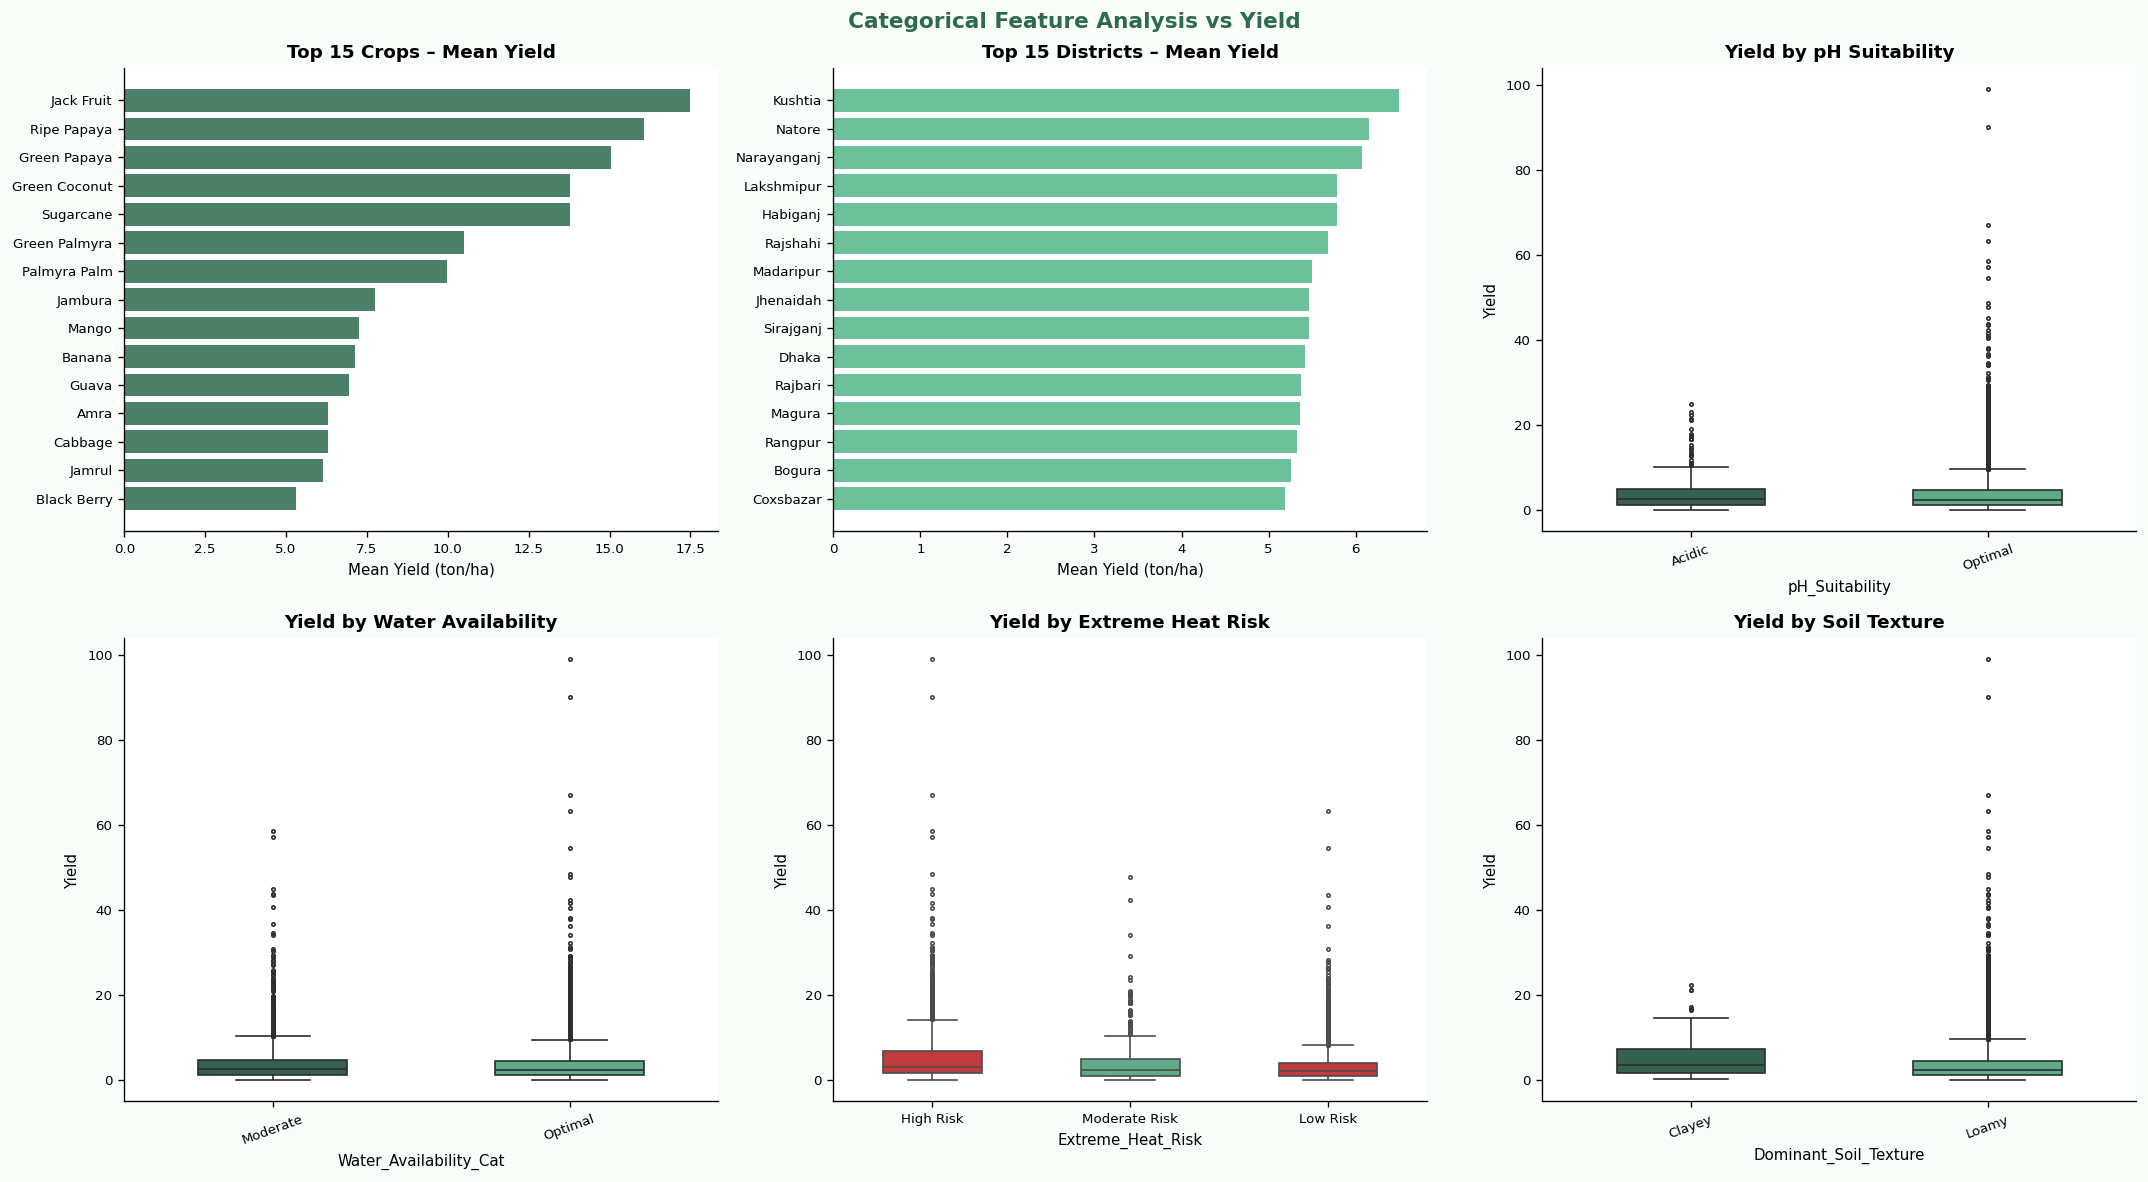

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor='#f8fdf9')
fig.patch.set_facecolor('#f8fdf9')

# Top 15 Crops by mean yield
top_crops = df.groupby('Crop Name')[target].mean().sort_values(ascending=False).head(15)
axes[0,0].barh(top_crops.index[::-1], top_crops.values[::-1], color=COLOR_MAIN, alpha=0.85)
axes[0,0].set_title('Top 15 Crops – Mean Yield', fontweight='bold')
axes[0,0].set_xlabel('Mean Yield (ton/ha)')

# Top 15 Districts
top_dist = df.groupby('District')[target].mean().sort_values(ascending=False).head(15)
axes[0,1].barh(top_dist.index[::-1], top_dist.values[::-1], color=COLOR_ACC, alpha=0.85)
axes[0,1].set_title('Top 15 Districts – Mean Yield', fontweight='bold')
axes[0,1].set_xlabel('Mean Yield (ton/ha)')

# pH Suitability
order_ph = df.groupby('pH_Suitability')[target].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='pH_Suitability', y=target, order=order_ph,
            ax=axes[0,2], palette=PALETTE[:len(order_ph)], width=0.5, fliersize=2)
axes[0,2].set_title('Yield by pH Suitability', fontweight='bold')
axes[0,2].tick_params(axis='x', rotation=20)

# Water Availability
order_w = df.groupby('Water_Availability_Cat')[target].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Water_Availability_Cat', y=target, order=order_w,
            ax=axes[1,0], palette=PALETTE[:len(order_w)], width=0.5, fliersize=2)
axes[1,0].set_title('Yield by Water Availability', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=20)

# Heat Risk
order_hr = df.groupby('Extreme_Heat_Risk')[target].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Extreme_Heat_Risk', y=target, order=order_hr,
            ax=axes[1,1], palette=['#d62728','#52b788'], width=0.5, fliersize=2)
axes[1,1].set_title('Yield by Extreme Heat Risk', fontweight='bold')

# Soil Texture
order_soil = df.groupby('Dominant_Soil_Texture')[target].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Dominant_Soil_Texture', y=target, order=order_soil,
            ax=axes[1,2], palette=PALETTE, width=0.5, fliersize=2)
axes[1,2].set_title('Yield by Soil Texture', fontweight='bold')
axes[1,2].tick_params(axis='x', rotation=20)

fig.suptitle('Categorical Feature Analysis vs Yield',
             fontsize=13, fontweight='bold', color=COLOR_MAIN)
plt.tight_layout()
plt.show()


## 8. Feature Distributions

Kiểm tra phân phối của 12 biến quan trọng nhất để phát hiện skewness và outliers.


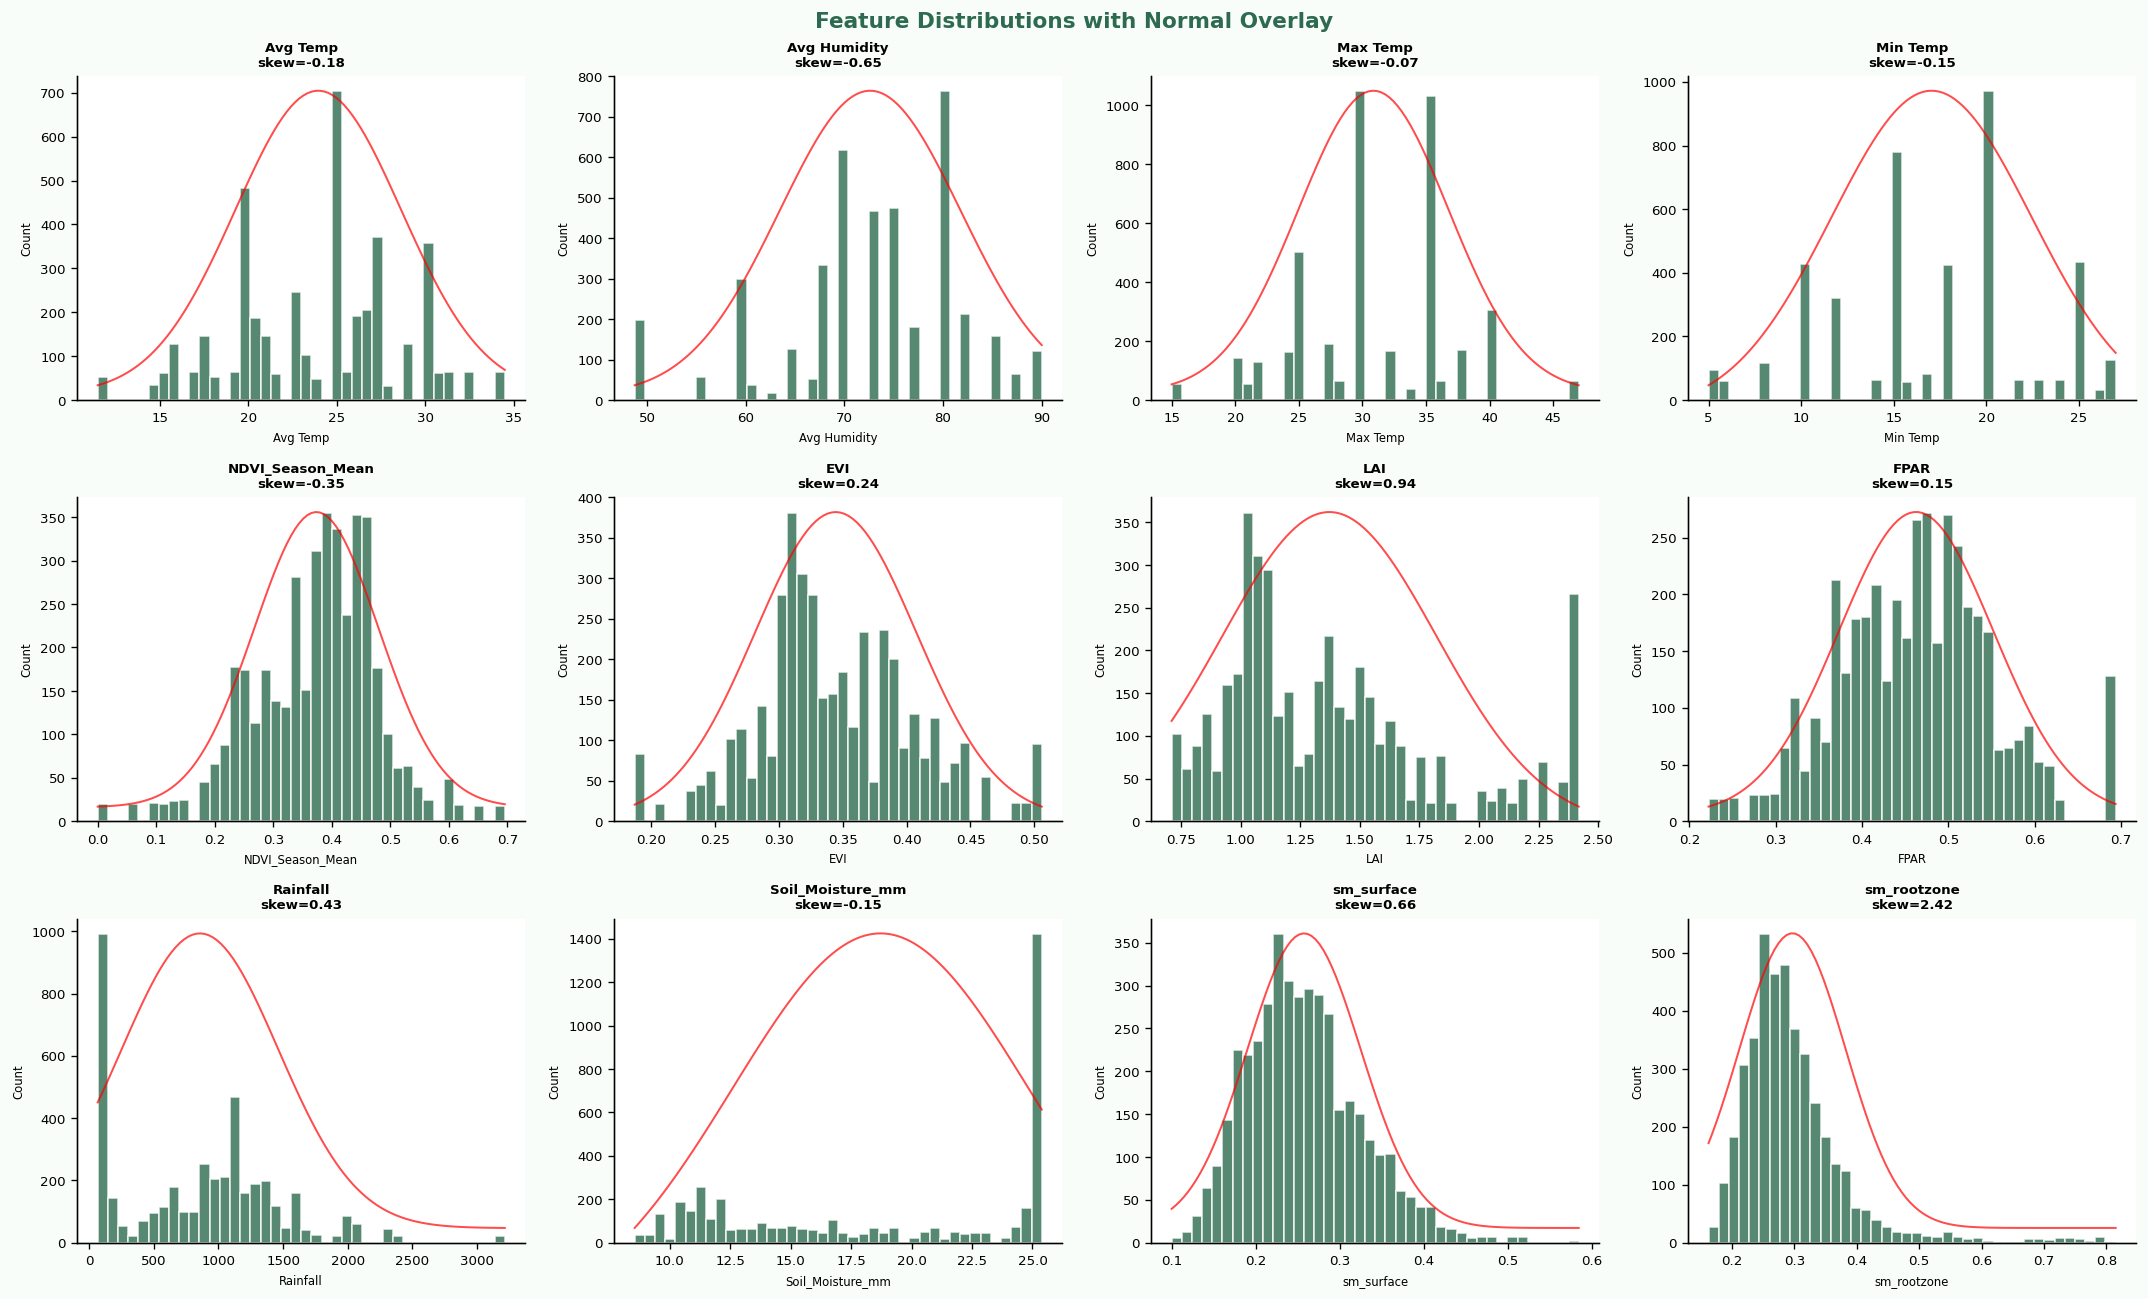

In [12]:
feat12 = key_features[:12]
fig, axes = plt.subplots(3, 4, figsize=(18, 11), facecolor='#f8fdf9')
fig.patch.set_facecolor('#f8fdf9')
axes = axes.flatten()

for i, feat in enumerate(feat12):
    ax   = axes[i]
    skew = df[feat].skew()
    ax.hist(df[feat].dropna(), bins=40, color=COLOR_MAIN, edgecolor='white', alpha=0.8)
    ax.set_title(f'{feat}\nskew={skew:.2f}', fontweight='bold', fontsize=8)
    ax.set_xlabel(feat, fontsize=7); ax.set_ylabel('Count', fontsize=7)
    mu, sigma = df[feat].mean(), df[feat].std()
    x = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax2 = ax.twinx()
    ax2.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=1.2, alpha=0.7)
    ax2.set_yticks([])
    ax2.spines['right'].set_visible(False); ax2.spines['top'].set_visible(False)

fig.suptitle('Feature Distributions with Normal Overlay',
             fontsize=13, fontweight='bold', color=COLOR_MAIN)
plt.tight_layout()
plt.show()


## 9. Multivariate Analysis – Climate Features by Season

Phân tích đa biến: quan sát NDVI, Rainfall, Temperature theo từng Season.


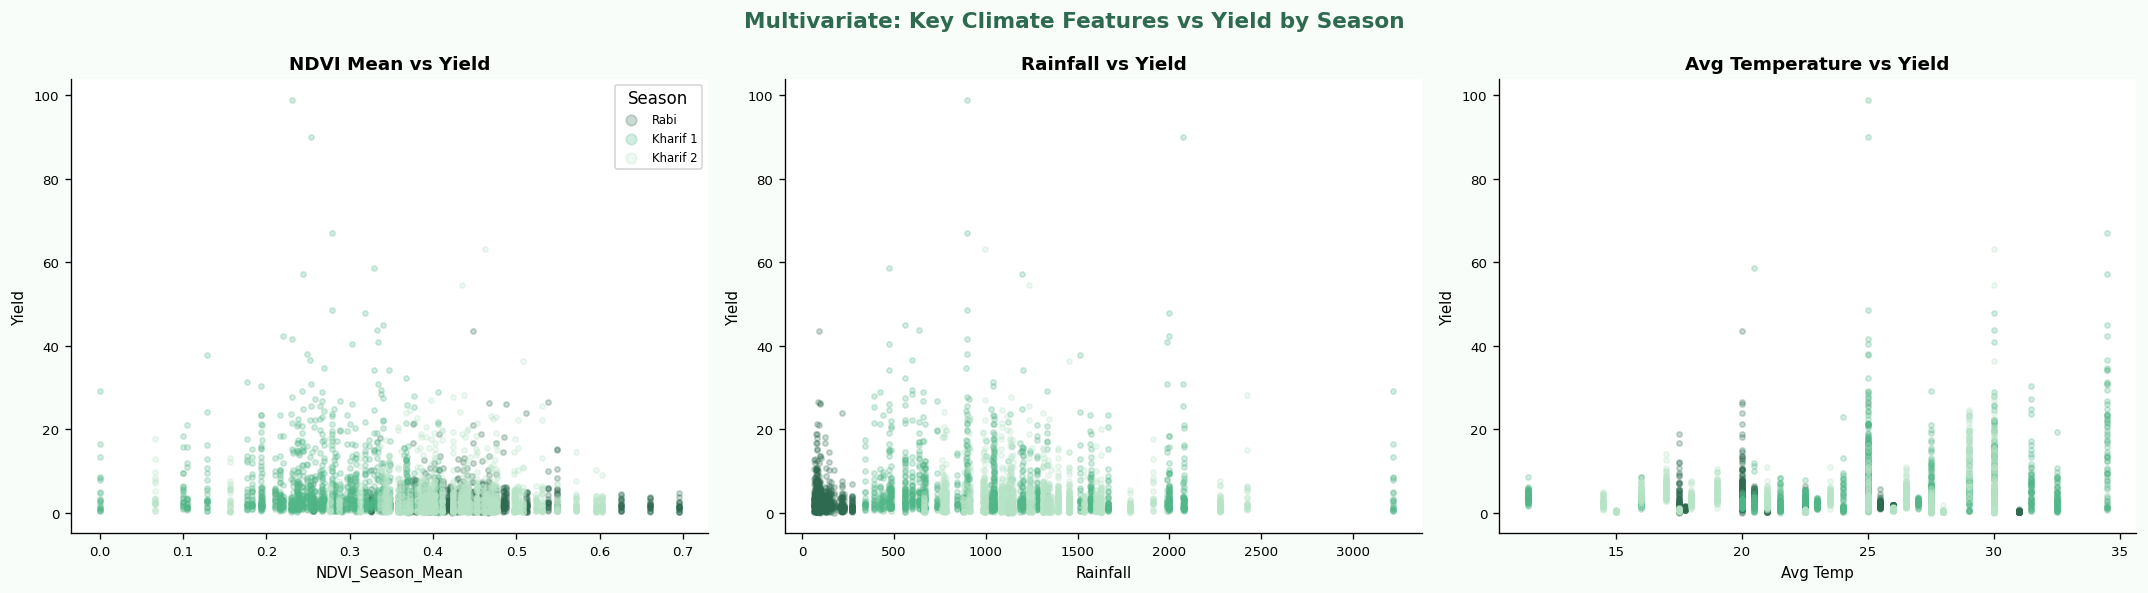

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='#f8fdf9')
fig.patch.set_facecolor('#f8fdf9')

seasons         = df['Season'].unique()
season_palette  = dict(zip(seasons, ['#2d6a4f','#52b788','#b7e4c7','#081c15']))

for ax, (x_feat, title) in zip(axes, [
    ('NDVI_Season_Mean', 'NDVI Mean vs Yield'),
    ('Rainfall',         'Rainfall vs Yield'),
    ('Avg Temp',         'Avg Temperature vs Yield'),
]):
    for season in seasons:
        sub = df[df['Season'] == season]
        ax.scatter(sub[x_feat], sub[target], alpha=0.25, s=10,
                   color=season_palette.get(season, 'gray'), label=season)
    ax.set_xlabel(x_feat, fontsize=9); ax.set_ylabel('Yield', fontsize=9)
    ax.set_title(title, fontweight='bold')

axes[0].legend(title='Season', fontsize=7, markerscale=2)
fig.suptitle('Multivariate: Key Climate Features vs Yield by Season',
             fontsize=13, fontweight='bold', color=COLOR_MAIN)
plt.tight_layout()
plt.show()


## 10. Outlier Analysis & Feature Importance

Phát hiện outliers bằng IQR method và so sánh correlation với raw Yield vs log(Yield).


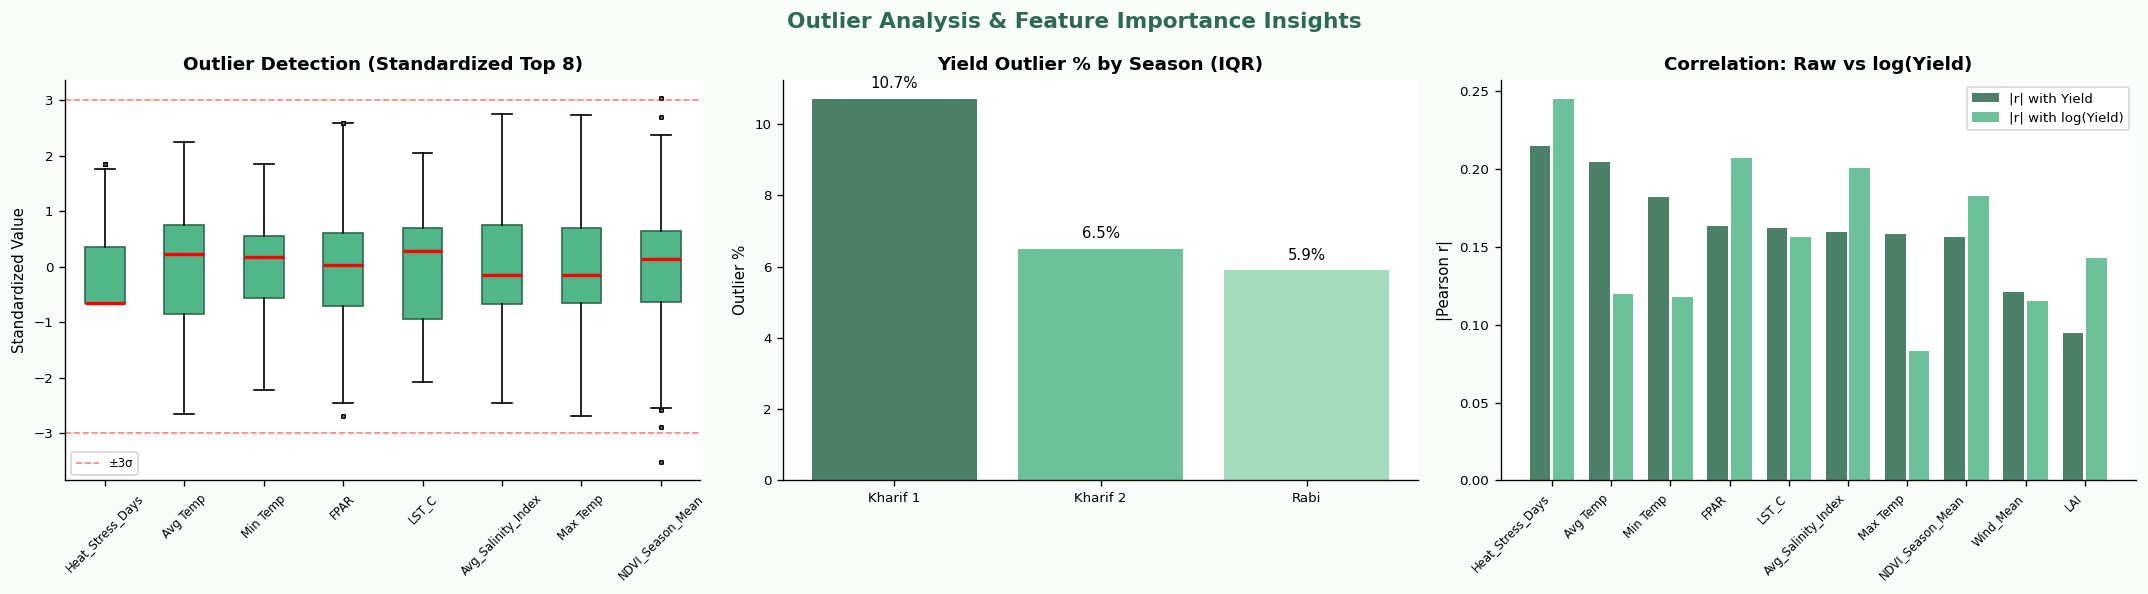

In [14]:
def count_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR    = Q3 - Q1
    return ((series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)).sum()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='#f8fdf9')
fig.patch.set_facecolor('#f8fdf9')

# Standardized boxplot (outlier detection)
scaler = StandardScaler()
scaled = pd.DataFrame(scaler.fit_transform(df[top8].fillna(df[top8].mean())), columns=top8)
axes[0].boxplot([scaled[c] for c in top8], labels=top8, vert=True, patch_artist=True,
                boxprops=dict(facecolor=COLOR_ACC, color=COLOR_MAIN),
                medianprops=dict(color='red', lw=2),
                flierprops=dict(marker='o', markerfacecolor='gray', markersize=2, alpha=0.3))
axes[0].set_title('Outlier Detection (Standardized Top 8)', fontweight='bold')
axes[0].set_ylabel('Standardized Value')
axes[0].tick_params(axis='x', rotation=45, labelsize=7)
axes[0].axhline(3,  color='red', lw=1, linestyle='--', alpha=0.5, label='±3σ')
axes[0].axhline(-3, color='red', lw=1, linestyle='--', alpha=0.5)
axes[0].legend(fontsize=7)

# Outlier % by season
outlier_pct = df.groupby('Season')[target].apply(
    lambda s: count_outliers(s) / len(s) * 100).sort_values(ascending=False)
axes[1].bar(outlier_pct.index, outlier_pct.values, color=PALETTE[:len(outlier_pct)], alpha=0.85)
axes[1].set_title('Yield Outlier % by Season (IQR)', fontweight='bold')
axes[1].set_ylabel('Outlier %')
for i, v in enumerate(outlier_pct.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

# Raw vs log(Yield) correlation comparison
corr_raw = df[key_features].corrwith(df[target]).abs().sort_values(ascending=False).head(10)
corr_log = df[key_features].corrwith(np.log1p(df[target])).abs()
x_pos = np.arange(len(corr_raw))
axes[2].bar(x_pos - 0.2, corr_raw.values, 0.35, label='|r| with Yield',       color=COLOR_MAIN, alpha=0.85)
axes[2].bar(x_pos + 0.2, [corr_log.get(k, 0) for k in corr_raw.index], 0.35,
            label='|r| with log(Yield)', color=COLOR_ACC, alpha=0.85)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(corr_raw.index, rotation=45, ha='right', fontsize=7)
axes[2].set_title('Correlation: Raw vs log(Yield)', fontweight='bold')
axes[2].set_ylabel('|Pearson r|')
axes[2].legend(fontsize=8)

fig.suptitle('Outlier Analysis & Feature Importance Insights',
             fontsize=13, fontweight='bold', color=COLOR_MAIN)
plt.tight_layout()
plt.show()


## 11. Key Insights & Recommendations for Regression Model

---

### 📌 Findings từ EDA:

| # | Insight | Chi tiết |
|---|---------|---------|
| 1 | **Yield bị lệch phải mạnh** | Skewness = 5.18 → dùng `log1p(Yield)` làm target |
| 2 | **Kharif 1 cho năng suất cao nhất** | Mean = 5.87 ton/ha vs Rabi = 2.96 |
| 3 | **Nhiệt độ tương quan dương** | Heat_Stress_Days, Avg Temp, Min Temp, LST_C |
| 4 | **NDVI/FPAR tương quan âm** | Các vùng NDVI cao → đất canh tác nhiều loại cây năng suất thấp hơn |
| 5 | **Data sạch hoàn toàn** | 0 missing values, không cần imputation |
| 6 | **72 loại cây trồng, 64 quận** | Cần encode cẩn thận (Label / Target Encoding) |

---

### 🔧 Recommended Features for Regression Model:


In [ ]:
# ── Final Feature Importance Ranking ─────────────────────────────────────────
print(" Feature Ranking by |Pearson r| with Yield:")
print("=" * 55)
important = corr_matrix[target].drop(target).abs().sort_values(ascending=False).head(15)
for i, (feat, val) in enumerate(important.items(), 1):
    bar = '█' * int(val * 50)
    print(f"  {i:2d}. {feat:35s}  {val:.4f}  {bar}")

print()
print(" Recommendation – Next Steps:")
print("  1. Transform target:  y = np.log1p(df['Yield'])")
print("  2. Encode categoricals: Season, Crop Name, District → Label/Target Encoding")
print("  3. Scale numeric features: StandardScaler()")
print("  4. Try models: Linear Regression → Ridge/Lasso → Random Forest → XGBoost")
print("  5. Evaluate with: R², RMSE, MAE on log scale, then inverse transform")


📊 Feature Ranking by |Pearson r| with Yield:
   1. Heat_Stress_Days                     0.2149  ██████████
   2. Avg Temp                             0.2047  ██████████
   3. Min Temp                             0.1821  █████████
   4. FPAR                                 0.1636  ████████
   5. LST_C                                0.1620  ████████
   6. Avg_Salinity_Index                   0.1597  ███████
   7. Max Temp                             0.1586  ███████
   8. NDVI_Season_Mean                     0.1563  ███████
   9. Wind_Mean                            0.1212  ██████
  10. LAI                                  0.0948  ████
  11. Avg Humidity                         0.0690  ███
  12. Clay                                 0.0640  ███
  13. Rainfall                             0.0632  ███
  14. Rain_Temp_Ratio                      0.0568  ██
  15. pH                                   0.0546  ██

💡 Recommendation – Next Steps:
  1. Transform target:  y = np.log1p(df['Yield'])
  2.